In [ ]:
from src.run import load_dataset, build_dataloader
from dataclasses import dataclass
import pprint
import torch
from src.models.backbone import ConditionalUNet1D


@dataclass
class DiffusionLunarLanderArgs:
    environment: str = "LunarLander-v3"
    horizon: int = 100
    batch_size: int = 32
    num_epochs: int = 10
    print_every: int = 1
    eval_every: int = 1
    lr: float = 1e-3
    hidden_dim: int = 64
    scheduler: str = "ddpm"
    num_train_timesteps: int = 1000
    num_inference_steps: int = 100
    inference_batch_size: int = 1
    condition_on: str = "start_obs_goal"
    model_type: str = "unet"
    model_target: str = "obs_act"
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"
    cfg: bool = True
    cfg_dropout_prob: float = 0.1
    guidance_scale: float = 1.0


args = DiffusionLunarLanderArgs()

config, minari_dataset, env = load_dataset(
    args, eval_env=True, env_render_mode="rgb_array"
)
action_dim = config.action_dim
obs_dim = config.obs_dim
input_dim = (obs_dim + action_dim) * args.horizon
cond_dim = obs_dim * 2
dataloader, minari_dataset_stats = build_dataloader(minari_dataset, args)
model_path = "src/checkpoints/DIFFUSION_LunarLander-v3_unet_h100_e10_k5_target-obs_act_cond-start_obs_goal_cfg.pth"
pp = pprint.PrettyPrinter(indent=2)
print("Dataset configuration:")
pp.pprint(config)
print("Training arguments:")
pp.pprint(vars(args))
state_dict = torch.load(model_path, map_location=args.device)
model = ConditionalUNet1D(
    horizon=args.horizon,
    input_dim=input_dim,
    hidden_dim=args.hidden_dim,
    cond_dim=cond_dim,
).to(args.device)
model.load_state_dict(state_dict)

Dataset configuration:
LunarLanderConfig(env_name='LunarLander-v3',
                  dataset_name='Box2D/LunarLanderContinuous-v3/expert-v0',
                  obs_dim=8,
                  action_dim=2,
                  category='Box2D')
Training arguments:
{ 'batch_size': 32,
  'cfg': True,
  'cfg_dropout_prob': 0.1,
  'condition_on': 'start_obs_goal',
  'device': 'cuda:0',
  'environment': 'LunarLander-v3',
  'eval_every': 1,
  'guidance_scale': 1.5,
  'hidden_dim': 64,
  'horizon': 100,
  'inference_batch_size': 1,
  'lr': 0.001,
  'model_target': 'obs_act',
  'model_type': 'unet',
  'num_epochs': 10,
  'num_inference_steps': 100,
  'num_train_timesteps': 1000,
  'print_every': 1,
  'scheduler': 'ddpm'}


<All keys matched successfully>

Target Start obs: (x=-0.0033, y=1.4210)
Target Goal obs:  (x=-0.0463, y=0.7058)
------------------------------
Start (x,y): (-0.0528, 0.8422)
End   (x,y): (-0.1711, 0.6694)
------------------------------
Start (x,y): (-0.0977, 0.9502)
End   (x,y): (-0.1669, 0.7970)
------------------------------
Start (x,y): (-0.0235, 0.8276)
End   (x,y): (-0.0628, 0.9007)
------------------------------
Start (x,y): (0.0022, 0.9443)
End   (x,y): (0.0157, 0.7413)
------------------------------
Start (x,y): (-0.0596, 0.7265)
End   (x,y): (-0.1049, 0.9454)
------------------------------


(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Trajectory Visualization'}>)

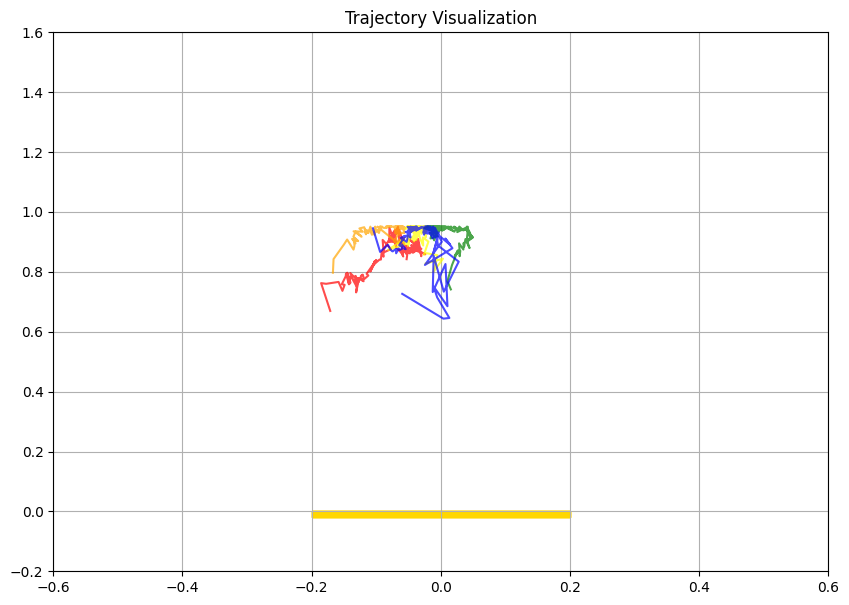

In [8]:
from src.pipelines.eval import evaluate_open_loop_diffusion
from src.diffusion import scheduler_map

noise_scheduler = scheduler_map[args.scheduler](args.num_train_timesteps)
evaluate_open_loop_diffusion(
    env=env,
    model=model,
    noise_scheduler=noise_scheduler,
    stats=minari_dataset_stats,
    input_dim=input_dim,
    args=args,
    logger=None,
    dataset=minari_dataset,
)

In [ ]:
# from src.pipelines.eval import evaluate_policy_mpc
# from src.pipelines.sampling import generate_diffusion_trajectory
# import random
# episode = minari_dataset[random.choice(range(len(minari_dataset)))]
# goal_obs = torch.from_numpy(episode.observations[-1]).to(args.device)
# print(goal_obs)
# diffusion_planner = lambda cond_dict: generate_diffusion_trajectory(
#     model=model,
#     noise_scheduler=noise_scheduler,
#     stats=minari_dataset_stats,
#     args=args,
#     input_dim=input_dim,
#     condition=cond_dict,
# )
# model_rewards = evaluate_policy_mpc(
#     env=env,
#     planner_fn=diffusion_planner,
#     num_episodes=10,
#     replan_freq=1,
#     render=False,
#     max_episode_length=300,
#     condition_type="start_obs_goal",
#     goal_obs=goal_obs
# )
# env.close()